In [ ]:
# Install dependencies
!pip install albumentations ultralytics tqdm wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.2 MB/s eta 0:00:00


In [ ]:
# Core imports
import random
import os
import shutil
import json
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import albumentations as A

# Set global seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ["WANDB_DISABLED"] = "true"

print('✅ Imports OK | Seeds locked to 42')

✅ Imports OK | Seeds locked to 42


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('✅ Drive mounted')

# force_remount=False avoids an extra auth prompt if already mounted.

Mounted at /content/drive
✅ Drive mounted


In [ ]:

# Paths
DATA_DIR    = Path('/content/drive/MyDrive/unzipped_Big_Cola/obj_train_data')  #  source images + labels (from google Drive)
OUTPUT_DIR  = Path('/content/augmented_data')                                  #  LOCAL (on colab env) for speed (faster than Drive)
NAMES_FILE  = Path('/content/drive/MyDrive/unzipped_Big_Cola/obj.names')
YAML_PATH   = Path('/content/big_cola.yaml')
WEIGHTS_DIR = Path('/content/drive/MyDrive/BigCola_runs')                      #  save best.pt here

# Dataset parameters
NUM_CLASSES  = 5          # classes 0–4
CLASS_NAMES  = ['Perfect_bottle', 'empty_bottle', 'no_cap', 'no_label', 'crooked_cap']
TARGET       = 250        # augmentation target count per class
VAL_RATIO    = 0.15       # 85/15 train/val split

# Training hyperparameters
EPOCHS   = 100
IMGSZ    = 640
BATCH    = 16
PATIENCE = 20   # early stopping: stop if no mAP improvement for 20 epochs

# Create dirs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'📂 Source data  : {DATA_DIR}')
print(f'📂 Augmented out: {OUTPUT_DIR}  (local — fast I/O)')
print(f'📂 Weights save : {WEIGHTS_DIR}')


📂 Source data  : /content/drive/MyDrive/unzipped_Big_Cola/obj_train_data
📂 Augmented out: /content/augmented_data  (local — fast I/O)
📂 Weights save : /content/drive/MyDrive/BigCola_runs


In [ ]:

#  CORE I/O FUNCTIONS


def read_yolo_labels(txt_path):
    """
    Parse a YOLO .txt label file.
    Returns list of [class_id, cx, cy, bw, bh] — all floats except class_id (int).

    Handles: '4', '4.0', '4.000' transparently via int(float()).
    Returns [] for missing or empty files (not an error — some images are background).
    """
    path = Path(txt_path)
    if not path.exists() or path.stat().st_size == 0:
        return []
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue  # skip malformed lines silently
            try:
                cls = int(float(parts[0]))   # handles '4.0' bug
                cx, cy, bw, bh = map(float, parts[1:])
                labels.append([cls, cx, cy, bw, bh])
            except ValueError:
                continue
    return labels


def save_yolo_labels(txt_path, labels):
    """
    Write YOLO labels to disk.
    Always writes integer class IDs — never floats.
    labels: list of [class_id, cx, cy, bw, bh]
    """
    with open(txt_path, 'w') as f:
        for row in labels:
            cls, cx, cy, bw, bh = row
            f.write(f'{int(cls)} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')


def is_valid_box(cx, cy, bw, bh):
    """Hard geometric validity gate — returns True only if box is physically sensible."""
    return (
        0 < bw <= 1 and
        0 < bh <= 1 and
        0 <= cx <= 1 and
        0 <= cy <= 1
    )


print('✅ I/O functions defined')


# NOTE: int(float()) not int() - because '4.0' breaks plain int()
# This was the bug that kept crashing Phase 1. One line fix.


✅ I/O functions defined


In [ ]:

#  SANITY CHECK -- image/label parity + structural issues

all_imgs  = sorted(DATA_DIR.glob('*.jpg')) + sorted(DATA_DIR.glob('*.png'))
all_txts  = sorted(DATA_DIR.glob('*.txt'))

img_stems = {p.stem for p in all_imgs}
txt_stems = {p.stem for p in all_txts}

imgs_no_label  = img_stems - txt_stems
labels_no_img  = txt_stems - img_stems

print(f'📊 Images found  : {len(all_imgs)}')
print(f'📊 Labels found  : {len(all_txts)}')
print(f'⚠️  Images w/o label: {len(imgs_no_label)}')
print(f'⚠️  Labels w/o image: {len(labels_no_img)}')

if imgs_no_label:
    print('\n❌ Images missing labels:')
    for s in sorted(imgs_no_label): print(f'  {s}')

if labels_no_img:
    print('\n❌ Orphan label files:')
    for s in sorted(labels_no_img): print(f'  {s}')

# Note: Set arithmetic (A - B) is the fastest way to find mismatches.
# This is O(n) and instantly highlights data collection errors.


📊 Images found  : 376
📊 Labels found  : 376
⚠️  Images w/o label: 0
⚠️  Labels w/o image: 0


In [ ]:

#  LABEL NORMALIZATION ----  run on SOURCE DATA_DIR before any copying
#  Fixes: float class IDs ('4.0'), invalid boxes


fixed_files   = 0
invalid_boxes = 0
float_cls_ids = 0

for txt_path in tqdm(sorted(DATA_DIR.glob('*.txt')), desc='Normalizing labels'):
    original_text = txt_path.read_text()
    labels = []

    for line in original_text.splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        try:
            cls = int(float(parts[0]))
            if '.' in parts[0]:           # was a float class ID
                float_cls_ids += 1
            cx, cy, bw, bh = map(float, parts[1:])

            if not is_valid_box(cx, cy, bw, bh):
                invalid_boxes += 1
                continue    # drop this box

            labels.append([cls, cx, cy, bw, bh])
        except ValueError:
            continue

    # Re-write only if something changed
    new_text = ''.join(f'{int(r[0])} {r[1]:.6f} {r[2]:.6f} {r[3]:.6f} {r[4]:.6f}\n' for r in labels)
    if new_text != original_text:
        txt_path.write_text(new_text)
        fixed_files += 1

print(f'\n✅ Normalization complete')
print(f'   Files rewritten  : {fixed_files}')
print(f'   Float class IDs  : {float_cls_ids}')
print(f'   Invalid boxes dropped: {invalid_boxes}')


# NOTE: This normalization pass runs on DATA_DIR (source), not OUTPUT_DIR.
# That way, the bug never propagates to any downstream copy.

Normalizing labels: 100%|██████████| 376/376 [02:08<00:00,  2.93it/s]


✅ Normalization complete
   Files rewritten  : 0
   Float class IDs  : 0
   Invalid boxes dropped: 0


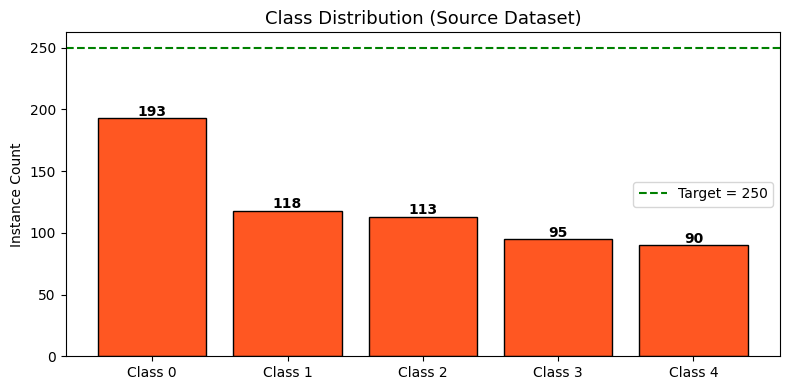


📊 Class distribution:
  Class 0:  193 instances  ⚠️  needs +57
  Class 1:  118 instances  ⚠️  needs +132
  Class 2:  113 instances  ⚠️  needs +137
  Class 3:   95 instances  ⚠️  needs +155
  Class 4:   90 instances  ⚠️  needs +160

⚠️  Empty label files: 0


In [ ]:
#  CLASS DISTRIBUTION ANALYSIS


class_counts  = Counter()
class_to_imgs = defaultdict(list)   # class_id [list of img paths that contain it]
empty_labels  = []

for img_path in sorted(DATA_DIR.glob('*.jpg')):
    txt_path = img_path.with_suffix('.txt')
    labels   = read_yolo_labels(txt_path)

    if not labels:
        empty_labels.append(img_path.name)
        continue

    for row in labels:
        cls = row[0]
        class_counts[cls] += 1
        class_to_imgs[cls].append(img_path)

#  Plot
fig, ax = plt.subplots(figsize=(8, 4))
classes = sorted(class_counts.keys())
counts  = [class_counts[c] for c in classes]
colors  = ['#2196F3' if class_counts[c] >= TARGET else '#FF5722' for c in classes]

bars = ax.bar([f'Class {c}' for c in classes], counts, color=colors, edgecolor='black')
ax.axhline(TARGET, color='green', linestyle='--', label=f'Target = {TARGET}')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(count),
            ha='center', fontweight='bold')
ax.set_title('Class Distribution (Source Dataset)', fontsize=13)
ax.set_ylabel('Instance Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n📊 Class distribution:')
for c in classes:
    deficit = max(0, TARGET - class_counts[c])
    status  = '✅' if deficit == 0 else f'⚠️  needs +{deficit}'
    print(f'  Class {c}: {class_counts[c]:>4} instances  {status}')

print(f'\n⚠️  Empty label files: {len(empty_labels)}')


# NOTE: Class imbalance in object detection is sneakier than classification.
# It's not just about image count -- it's about INSTANCE count per class.
# One image can have 3 bottles of class 2 and 0 of class 4.
# The bar chart above shows INSTANCES not images.

In [ ]:
#  DATASET INTEGRITY HASH
#  Compute a fingerprint of your source dataset before augmentation.

def compute_dataset_hash(directory):
    """SHA-256 fingerprint of all .txt files sorted by name."""
    h = hashlib.sha256()
    for txt in sorted(Path(directory).glob('*.txt')):
        h.update(txt.read_bytes())
    return h.hexdigest()[:16]   # first 16 chars is enough

DATASET_HASH = compute_dataset_hash(DATA_DIR)
print(f'🔑 Source dataset label hash: {DATASET_HASH}')
print('   → Save this. If it changes unexpectedly, your source was modified.')

🔑 Source dataset label hash: 26a0b22513643732
   → Save this. If it changes unexpectedly, your source was modified.


/tmp/ipykernel_2523/2975354864.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap('tab10', NUM_CLASSES)


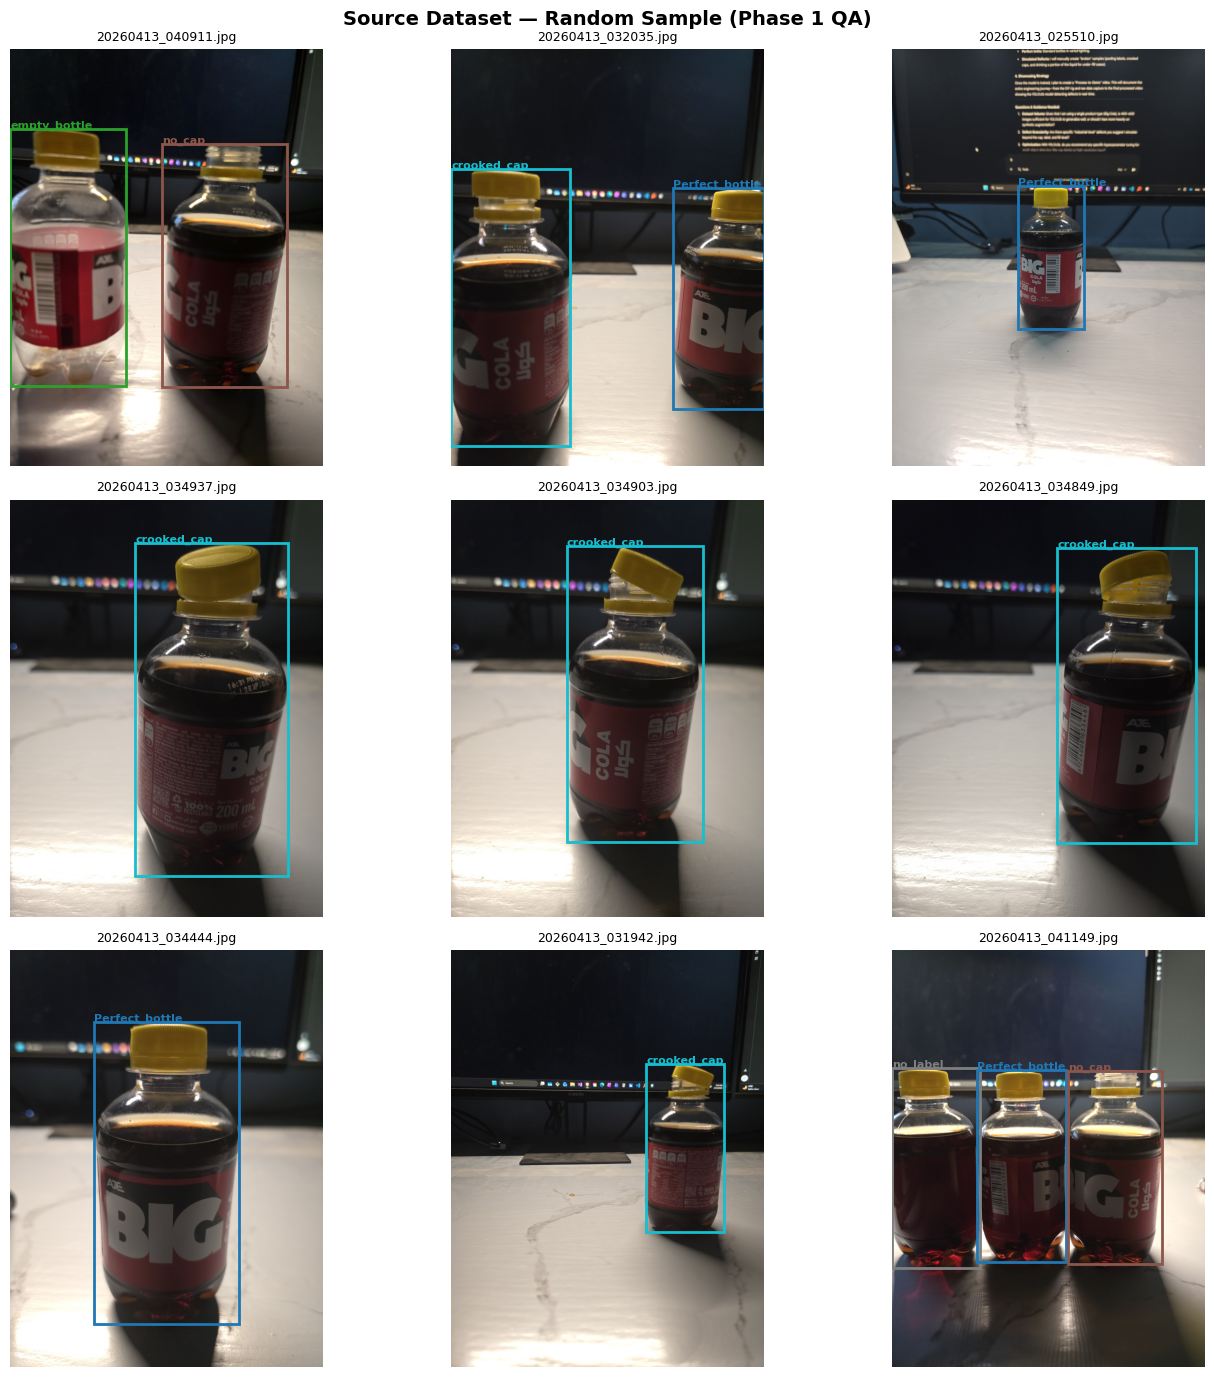

In [ ]:
#  VISUALIZE 9 RANDOM ANNOTATED SAMPLES === human eye check
COLORS = plt.colormaps['tab10']

def draw_boxes(img_path, ax=None, title=None):
    """Draw YOLO bounding boxes on an image. Returns False if image unreadable."""
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    labels = read_yolo_labels(img_path.with_suffix('.txt'))

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img)

    for row in labels:
        cls, cx, cy, bw, bh = row
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                   linewidth=2, edgecolor=COLORS(cls), facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, CLASS_NAMES[cls], color=COLORS(cls), fontsize=8, fontweight='bold')

    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=9)
    return True


# Sample 9 random images
sample_imgs = random.sample(list(DATA_DIR.glob('*.jpg')), min(9, len(list(DATA_DIR.glob('*.jpg')))))
fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for ax, img_path in zip(axes.flat, sample_imgs):
    draw_boxes(img_path, ax=ax, title=img_path.name)

plt.suptitle('Source Dataset — Random Sample (Phase 1 QA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#  PHASE 1 GATE; only proceed if zero issues


# Rescan for any remaining float class IDs
float_issues = 0
for txt in DATA_DIR.glob('*.txt'):
    for line in txt.read_text().splitlines():
        parts = line.strip().split()
        if parts and '.' in parts[0]:
            float_issues += 1

assert float_issues == 0, f'❌ Still {float_issues} float class IDs in source data — fix before continuing'
assert len(imgs_no_label) == 0, f'❌ {len(imgs_no_label)} images have no label — fix before continuing'

print('✅ Phase 1 GATE PASSED — zero float class IDs, zero missing labels')
print('   → Safe to proceed to Phase 2 (Augmentation)')


✅ Phase 1 GATE PASSED — zero float class IDs, zero missing labels
   → Safe to proceed to Phase 2 (Augmentation)


In [ ]:
#  AUGMENTATION TRANSFORMS ---- tested safe values
bbox_params = A.BboxParams(
    format='yolo',               #  raw [cx,cy,bw,bh] => let Albumentations handle math
    label_fields=['class_labels'],
    min_visibility=0.4,          # drop boxes that become < 40% visible after transform
    clip=True                    # clamp boxes to image bounds
)

# General transform: balance class distribution
general_transform = A.Compose([
    A.HorizontalFlip(p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.5),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.3),
    A.Perspective(scale=(0.01, 0.04), p=0.4),    # max 0.04 -- above 0.05 distorts boxes
    A.Affine(
        translate_percent={'x': (-0.03, 0.03), 'y': (-0.02, 0.02)},  # max 0.03 -- safe zone
        rotate=(-3, 3),           #  bottles are vertical -- minimal rotation
        scale=(0.90, 1.10),
        p=0.5
    ),
], bbox_params=bbox_params)

# Motion transform: simulate conveyor belt blur
motion_transform = A.Compose([
    A.MotionBlur(blur_limit=(3, 7), p=0.8),      #  max 7 -- above 9 over-blurs small bottles
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.1, p=0.4),
    A.Affine(
        translate_percent={'x': (-0.02, 0.02), 'y': (-0.01, 0.01)},
        rotate=(-1, 1),
        scale=(0.95, 1.05),
        p=0.4
    ),
], bbox_params=bbox_params)

print('✅ Augmentation transforms defined')
print('   general_transform : geometric + photometric (class balancing)')
print('   motion_transform  : MotionBlur + subtle shift (conveyor simulation)')

# NOTE: Why format='yolo' and NOT manual conversion?
#The original pipeline manually converted [cx,cy,bw,bh] to [x_min,y_min,x_max,y_max]
#but declared format='yolo'. Albumentations then reinterpreted the ALREADY converted values as YOLO.
# Result: wildly wrong boxes -- no error, just silent bad data.
# FIX: Pass raw YOLO values. Declare format='yolo'.
# ─────────────────────────────────────────────────────────────────────────────

✅ Augmentation transforms defined
   general_transform : geometric + photometric (class balancing)
   motion_transform  : MotionBlur + subtle shift (conveyor simulation)


/tmp/ipykernel_2523/2063503021.py:18: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 40.0), p=0.3),


In [ ]:
def augment_and_save(img_path, txt_path, out_img_path, out_txt_path, transform):
    """
    Apply one augmentation to one image+label pair and save to disk.
    Returns True on success, False if transform drops all boxes.

    IMPORTANT: Does NOT use atomic write for simplicity.
    For production, write to a .tmp file first, then rename (atomic on Linux).
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    labels = read_yolo_labels(txt_path)
    if not labels:
        return False

    bboxes       = [[r[1], r[2], r[3], r[4]] for r in labels]
    class_labels = [r[0] for r in labels]

    try:
        result = transform(image=img, bboxes=bboxes, class_labels=class_labels)
    except Exception:
        return False

    if not result['bboxes']:    # all boxes were dropped by min_visibility filter
        return False

    aug_img    = cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
    aug_labels = [[cls, *box] for cls, box in zip(result['class_labels'], result['bboxes'])]

    # Validate boxes before writing
    aug_labels = [r for r in aug_labels if is_valid_box(r[1], r[2], r[3], r[4])]
    if not aug_labels:
        return False

    cv2.imwrite(str(out_img_path), aug_img, [cv2.IMWRITE_JPEG_QUALITY, 95])
    save_yolo_labels(out_txt_path, aug_labels)
    return True

print('✅ augment_and_save() defined')

# (Atomic Write): For production, replace the last two lines with:
#    Write to temp file first, then rename:
#    tmp = out_img_path.with_suffix('.tmp.jpg')
#    cv2.imwrite(str(tmp), aug_img, [cv2.IMWRITE_JPEG_QUALITY, 95])
#    tmp.rename(out_img_path)   # atomic on Linux
#    This prevents partial .jpg files on disk if the process crashes mid-write.
#
#    cv2.IMWRITE_JPEG_QUALITY=95 prevents silent JPEG quality degradation.
#    Default JPEG quality is ~95 in OpenCV, but making it explicit with the intent.

✅ augment_and_save() defined


In [ ]:

#  RUN AUGMENTATION
#  Step 1: Wipe OUTPUT_DIR
#  Step 2: Copy originals
#  Step 3: Targeted augmentation per class
# ==========================================

#  Step 1: Wipe OUTPUT_DIR
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
    print(f'🗑️  Wiped: {OUTPUT_DIR}')
OUTPUT_DIR.mkdir(parents=True)


# Always wipe OUTPUT_DIR before re-running - stale files from a previous
# broken run caused me an hour of debugging (Bug #3 in my post-mortem)

# Step 2: Copy originals into OUTPUT_DIR
print('Copying originals...')
for img_path in tqdm(sorted(DATA_DIR.glob('*.jpg')), desc='Copying'):
    txt_path = img_path.with_suffix('.txt')
    if txt_path.exists():
        shutil.copy2(img_path, OUTPUT_DIR / img_path.name)
        shutil.copy2(txt_path, OUTPUT_DIR / txt_path.name)

print(f'✅ Copied {len(list(OUTPUT_DIR.glob("*.jpg")))} image+label pairs to OUTPUT_DIR')

# Step 3: Compute per-class deficits
augmentations_needed = {cls: max(0, TARGET - class_counts[cls]) for cls in range(NUM_CLASSES)}

# Class 3 (no_label) was most underrepresented -- extra 50 samples added manually
augmentations_needed[3] = augmentations_needed[3] + 50
print('\n📊 Augmentations needed per class:')
for cls, need in augmentations_needed.items():
    print(f'  Class {cls}: +{need}')

🗑️  Wiped: /content/augmented_data
Copying originals...


Copying: 100%|██████████| 376/376 [03:32<00:00,  1.77it/s]

✅ Copied 376 image+label pairs to OUTPUT_DIR

📊 Augmentations needed per class:
  Class 0: +57
  Class 1: +132
  Class 2: +137
  Class 3: +205
  Class 4: +160


In [ ]:
# Step 4: Targeted augmentation loop
aug_counters  = Counter()   # how many augmented images we've made per class
aug_failures  = Counter()   # how many failed (boxes dropped, etc.)


for cls_id in range(NUM_CLASSES):
    needed = augmentations_needed[cls_id]
    if needed == 0:
        print(f'  Class {cls_id}: already at target, skipping')
        continue

    source_imgs = class_to_imgs.get(cls_id, [])
    if not source_imgs:
        print(f'  ⚠️  Class {cls_id}: no source images found — cannot augment')
        continue

    print(f'\nAugmenting class {cls_id}: need {needed} more samples...')
    cycle_iter = iter(source_imgs * (needed // len(source_imgs) + 2))  # cycle through sources

    with tqdm(total=needed, desc=f'  Class {cls_id}') as pbar:
        while aug_counters[cls_id] < needed:
            try:
                src_img = next(cycle_iter)
            except StopIteration:
                break

            src_txt = src_img.with_suffix('.txt')
            idx     = aug_counters[cls_id] + aug_failures[cls_id]
            stem    = src_img.stem

            # Alternate between general and motion transforms
            transform = general_transform if idx % 3 != 0 else motion_transform

            out_img = OUTPUT_DIR / f'{stem}_cls{cls_id}_{aug_counters[cls_id]:04d}.jpg'
            out_txt = OUTPUT_DIR / f'{stem}_cls{cls_id}_{aug_counters[cls_id]:04d}.txt'

            success = augment_and_save(src_img, src_txt, out_img, out_txt, transform)

            if success:
                aug_counters[cls_id] += 1
                pbar.update(1)
            else:
                aug_failures[cls_id] += 1

print('\n✅ Augmentation complete!')
print(f'   Generated : {dict(aug_counters)}')
print(f'   Failures  : {dict(aug_failures)}')
total_files = len(list(OUTPUT_DIR.glob('*.jpg')))
print(f'   Total images in OUTPUT_DIR: {total_files}')

# Why cycle through source images?
#    If class 3 has only 30 images but needs 200, we cycle through the 30 repeatedly, applying different random transforms each time.
#    Each pass through the same image produces a different augmented version because transforms use random parameters.


Augmenting class 0: need 57 more samples...


  Class 0: 100%|██████████| 57/57 [00:38<00:00,  1.49it/s]



Augmenting class 1: need 132 more samples...


  Class 1: 100%|██████████| 132/132 [01:20<00:00,  1.64it/s]



Augmenting class 2: need 137 more samples...


...


Augmenting class 3: need 205 more samples...


  Class 3: 100%|██████████| 205/205 [02:01<00:00,  1.68it/s]



Augmenting class 4: need 160 more samples...


  Class 4: 100%|██████████| 160/160 [01:37<00:00,  1.64it/s]


✅ Augmentation complete!
   Generated : {0: 57, 1: 132, 2: 137, 3: 205, 4: 160}
   Failures  : {}
   Total images in OUTPUT_DIR: 1067


In [ ]:
#  POST-AUGMENTATION AUTOMATED VALIDITY SCAN

scan_errors  = []
scan_deleted = 0

for txt_path in tqdm(sorted(OUTPUT_DIR.glob('*.txt')), desc='Validity scan'):
    labels = read_yolo_labels(txt_path)

    # Check for float class IDs
    for line in txt_path.read_text().splitlines():
        parts = line.strip().split()
        if parts and '.' in parts[0]:
            scan_errors.append(f'Float class ID: {txt_path.name}')

    # Check for invalid boxes
    valid = [r for r in labels if is_valid_box(r[1], r[2], r[3], r[4])]
    if len(valid) != len(labels):
        scan_errors.append(f'Invalid boxes: {txt_path.name} ({len(labels)-len(valid)} bad)')
        # Nuclear clean: rewrite with only valid boxes; delete pair if empty
        if valid:
            save_yolo_labels(txt_path, valid)
        else:
            txt_path.unlink()
            img_path = txt_path.with_suffix('.jpg')
            if img_path.exists(): img_path.unlink()
            scan_deleted += 1

print(f'\n✅ Validity scan complete')
print(f'   Issues found  : {len(scan_errors)}')
print(f'   Pairs deleted : {scan_deleted}')

if scan_errors:
    print('\n⚠️  First 10 errors:')
    for e in scan_errors[:10]: print(f'  {e}')

# Hard gate
# After scan, rebuild class distribution
final_counts = Counter()
for txt_path in OUTPUT_DIR.glob('*.txt'):
    for row in read_yolo_labels(txt_path):
        final_counts[row[0]] += 1

print('\n📊 Final class distribution after augmentation:')
for c in sorted(final_counts): print(f'  Class {c}: {final_counts[c]}')

Validity scan: 100%|██████████| 1067/1067 [00:00<00:00, 18139.57it/s]


✅ Validity scan complete
   Issues found  : 0
   Pairs deleted : 0

📊 Final class distribution after augmentation:
  Class 0: 551
  Class 1: 342
  Class 2: 352
  Class 3: 344
  Class 4: 310


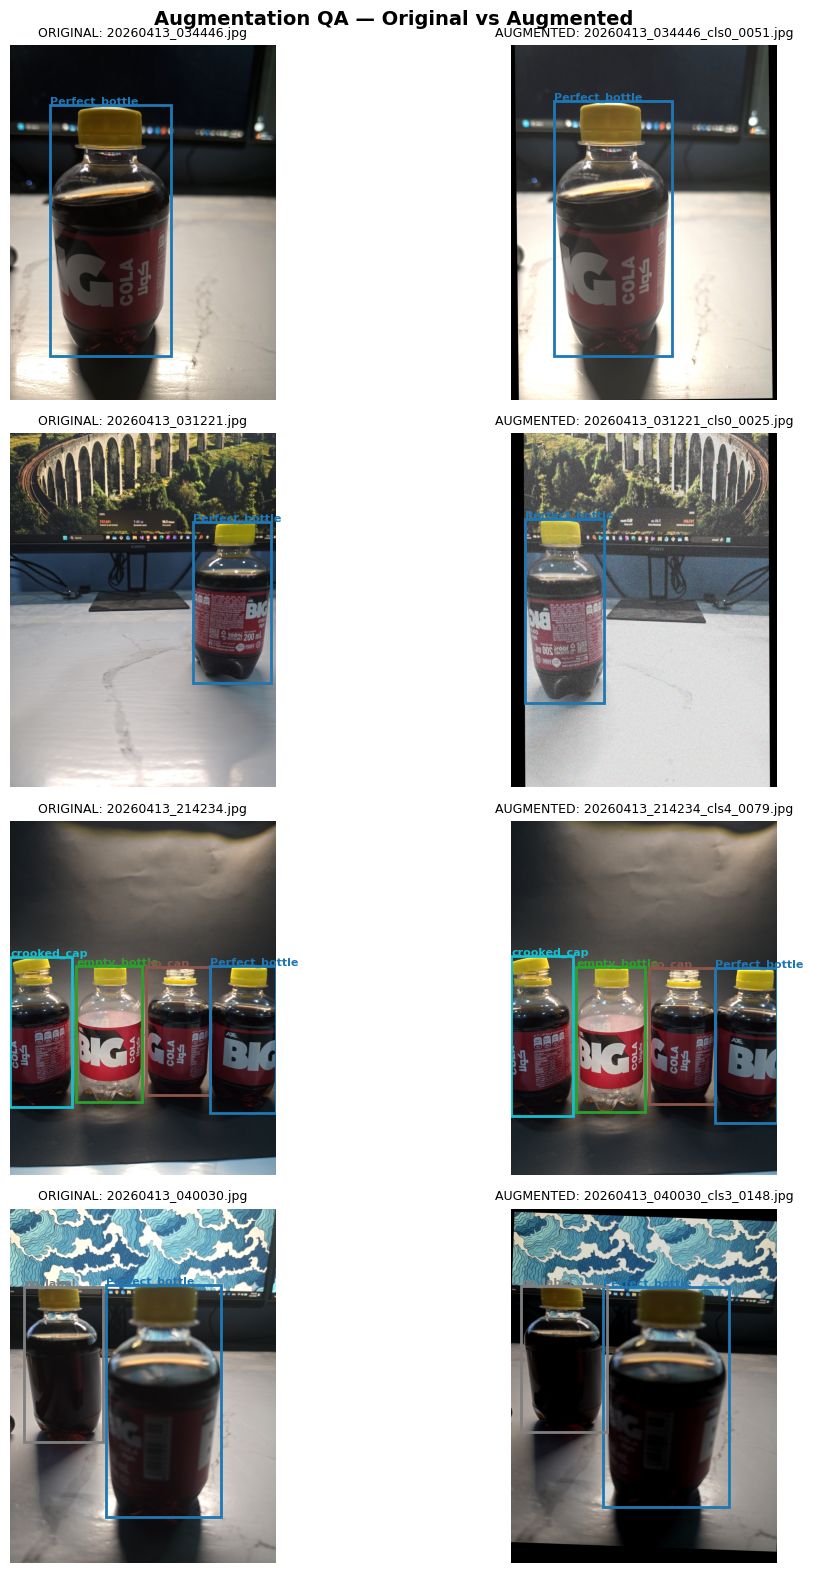

In [ ]:
# Show 4 original / augmented side by side images
#  Confirm boxes are tight on bottles - not floating or outside object

# Rebuild stem_to_imgs AFTER any deletion pass
stem_to_imgs = defaultdict(lambda: {'orig': [], 'aug': []})
for img_path in OUTPUT_DIR.glob('*.jpg'):
    # Augmented files contain '_cls' in their name
    if '_cls' in img_path.stem:
        # Extract original stem from augmented name: 'img001_cls2_0003' → 'img001'
        orig_stem = img_path.stem.rsplit('_cls', 1)[0]
        stem_to_imgs[orig_stem]['aug'].append(img_path)
    else:
        stem_to_imgs[img_path.stem]['orig'].append(img_path)

# Filter to stems that have BOTH original and augmented
stems_with_both = [s for s, v in stem_to_imgs.items() if v['orig'] and v['aug']]

if len(stems_with_both) >= 4:
    sample_stems = random.sample(stems_with_both, 4)
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))

    for i, stem in enumerate(sample_stems):
        orig_img = stem_to_imgs[stem]['orig'][0]
        aug_img  = random.choice(stem_to_imgs[stem]['aug'])

        draw_boxes(orig_img, ax=axes[i][0], title=f'ORIGINAL: {orig_img.name}')
        draw_boxes(aug_img,  ax=axes[i][1], title=f'AUGMENTED: {aug_img.name}')

    plt.suptitle('Augmentation QA — Original vs Augmented', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  Not enough stems with both orig+aug to show pairs. Check augmentation ran.')


In [ ]:
#  LEAKAGE-SAFE TRAIN/VAL SPLIT

# Group all files in OUTPUT_DIR by original stem
stem_to_files = defaultdict(list)
for img_path in sorted(OUTPUT_DIR.glob('*.jpg')):
    if img_path.with_suffix('.txt').exists():   # only complete pairs
        orig_stem = img_path.stem.rsplit('_cls', 1)[0] if '_cls' in img_path.stem else img_path.stem
        stem_to_files[orig_stem].append(img_path)

all_stems = sorted(stem_to_files.keys())
random.shuffle(all_stems)   # shuffle at stem level, not file level

split_idx  = int(len(all_stems) * (1 - VAL_RATIO))
train_stems = set(all_stems[:split_idx])
val_stems   = set(all_stems[split_idx:])

# Verify no overlap
overlap = train_stems & val_stems
assert len(overlap) == 0, f'❌ DATA LEAKAGE: {len(overlap)} stems appear in both splits!'

# Write .txt manifest files that YOLO reads
train_paths = []
val_paths   = []

for stem in all_stems:
    for img_path in stem_to_files[stem]:
        if stem in train_stems:
            train_paths.append(str(img_path))
        else:
            val_paths.append(str(img_path))

TRAIN_TXT = Path('/content/train_aug.txt')
VAL_TXT   = Path('/content/val_aug.txt')

TRAIN_TXT.write_text('\n'.join(train_paths))
VAL_TXT.write_text('\n'.join(val_paths))

print(f'✅ Split complete — zero data leakage')
print(f'   Train images : {len(train_paths)}  ({len(train_stems)} unique scenes)')
print(f'   Val images   : {len(val_paths)}  ({len(val_stems)} unique scenes)')
print(f'   Manifests    : {TRAIN_TXT}  |  {VAL_TXT}')


# What is data leakage in a split?
#    If image 'bottle_023.jpg' is in train AND 'bottle_023_cls2_0001.jpg'
#    (its augmented version) is in val, your model has SEEN the val scene
#    during training. mAP will look great but won't generalize to new video.
#    The fix: split by stem (original image), not by individual file.
# (original and augmented are in the same split)


✅ Split complete — zero data leakage
   Train images : 907  (319 unique scenes)
   Val images   : 160  (57 unique scenes)
   Manifests    : /content/train_aug.txt  |  /content/val_aug.txt


In [ ]:

#  WRITE big_cola.yaml

import yaml

yaml_content = {
    'path'  : str(OUTPUT_DIR),
    'train' : str(TRAIN_TXT),
    'val'   : str(VAL_TXT),
    'nc'    : NUM_CLASSES,
    'names' : CLASS_NAMES
}

with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f'✅ YAML written to {YAML_PATH}')
print(yaml.dump(yaml_content, default_flow_style=False, sort_keys=False))

✅ YAML written to /content/big_cola.yaml
path: /content/augmented_data
train: /content/train_aug.txt
val: /content/val_aug.txt
nc: 5
names:
- Perfect_bottle
- empty_bottle
- no_cap
- no_label
- crooked_cap



In [ ]:
# If you get a FileNotFoundError on BASE_YAML here, your runtime
# disconnected before the YAML cell saved. Re-run the YAML cell above first.
# BASELINE RUN -- originals only (NO augmentation)

from ultralytics import YOLO

# Write baseline yaml (originals only)
baseline_imgs = [str(p) for p in sorted(DATA_DIR.glob('*.jpg')) if p.with_suffix('.txt').exists()]
n_val_base    = int(len(baseline_imgs) * VAL_RATIO)
random.shuffle(baseline_imgs)

BASE_TRAIN_TXT = Path('/content/train_base.txt')
BASE_VAL_TXT   = Path('/content/val_base.txt')
BASE_TRAIN_TXT.write_text('\n'.join(baseline_imgs[n_val_base:]))
BASE_VAL_TXT.write_text('\n'.join(baseline_imgs[:n_val_base]))

BASE_YAML = Path('/content/big_cola_base.yaml')
base_yaml_content = yaml_content.copy()
base_yaml_content['train'] = str(BASE_TRAIN_TXT)
base_yaml_content['val']   = str(BASE_VAL_TXT)
with open(BASE_YAML, 'w') as f:
    yaml.dump(base_yaml_content, f, default_flow_style=False, sort_keys=False)

# Train baseline
model_base = YOLO('yolo26n.pt')

results_base = model_base.train(
    data      = str(BASE_YAML),
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    optimizer = 'AdamW',
    patience  = PATIENCE,
    plots     = True,
    project   = str(WEIGHTS_DIR),
    name      = 'baseline_originals',
    seed      = SEED,
    verbose   = True
)

print('\n✅ BASELINE TRAINING COMPLETE')
print(f'   Best weights: {WEIGHTS_DIR}/baseline_originals/weights/best.pt')

# NOTE: The baseline run is super important.
# Without it I cannot answer: "Did the ugmentation actually help?"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


KeyboardInterrupt: 

In [ ]:
#  EXPERIMENT RUN -- augmented dataset

model_aug = YOLO('yolo26n.pt')

results_aug = model_aug.train(
    data      = str(YAML_PATH),
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    optimizer = 'AdamW',
    patience  = PATIENCE,
    plots     = True,
    project   = str(WEIGHTS_DIR),
    name      = 'experiment_augmented',
    seed      = SEED,
    verbose   = True
)

print('\n✅ AUGMENTED TRAINING COMPLETE')
print(f'   Best weights: {WEIGHTS_DIR}/experiment_augmented/weights/best.pt')

# we use the same seed for both runs.
#    Different seeds introduce variance that makes it hard to attribute performance differences to augmentation vs luck of the shuffle.

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/big_cola.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=experiment_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

In [ ]:
#  RESUME AUGMENTED TRAINING — after Colab GPU limit interruption

from ultralytics import YOLO

# last.pt = checkpoint from the exact epoch where training stopped
LAST_PT = WEIGHTS_DIR / 'experiment_augmented' / 'weights' / 'last.pt'

assert LAST_PT.exists(), f'❌ Cannot find last.pt at {LAST_PT} — check your Drive path'
print(f'✅ Found checkpoint: {LAST_PT}')

model_resume = YOLO(str(LAST_PT))

# resume=True tells YOLO to pick up from the saved epoch, optimizer state,
# scheduler state - everything. It reads all config from the checkpoint itself.
results_aug = model_resume.train(
    resume = True
)

print('\n✅ RESUMED TRAINING COMPLETE')
print(f'   Best weights: {WEIGHTS_DIR}/experiment_augmented/weights/best.pt')

# NOTE: resume=True restores the FULL training state from last.pt:
#    - epoch counter (continues from 93, not from 0)
#    - optimizer momentum and learning rate schedule
#    - best mAP seen so far (for early stopping logic)
#    Without this, you'd be starting a brand new run, not continuing the old one.
#
# NOTE: last.pt vs best.pt:
#    last.pt = weights from the most recent epoch (your resume checkpoint)
#    best.pt = weights from the epoch with highest mAP (your deployment model)
#    Always resume from last.pt. Deploy best.pt.

✅ Found checkpoint: /content/drive/MyDrive/BigCola_runs/experiment_augmented/weights/last.pt
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/big_cola.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/BigCola_runs/experiment_augmented/weights/last.pt, momentum=0.937,

In [ ]:
#  EXTENDED TRAINING (becuse colab runtime limit)
#  (we use best.pt as starting point and not the last.pt)

from ultralytics import YOLO
BEST_PT = WEIGHTS_DIR / 'experiment_augmented' / 'weights' / 'best.pt'

model_extended = YOLO(str(BEST_PT))

results_extended = model_extended.train(
    data      = str(YAML_PATH),
    epochs    = 50,           # additional epochs budget
    imgsz     = IMGSZ,
    batch     = BATCH,
    optimizer = 'AdamW',
    patience  = 15,           # tighter patience — stop faster if already converged
    lr0       = 0.0001,       # ← LOWER learning rate for fine-tuning
    lrf       = 0.01,
    plots     = True,
    project   = str(WEIGHTS_DIR),
    name      = 'experiment_extended',   # new folder — keeps original run clean
    seed      = SEED,
    verbose   = True
)

# Fine-tuning from best.pt with a lower lr0 (0.0001 vs default 0.01) is how you squeeze the last 1-2% mAP50-95 out of a model that's
# already near-converged. Starting from last.pt with the same lr would
# just oscillate around the same minimum.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/big_cola.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

In [ ]:
#  EVALUATE AUGMENTED MODEL ONLY (baseline run pending)

from ultralytics import YOLO
from pathlib import Path

BEST_AUG  = WEIGHTS_DIR / 'experiment_augmented' / 'weights' / 'best.pt'

assert BEST_AUG.exists(), f'❌ best.pt not found at {BEST_AUG}'

model_aug = YOLO(str(BEST_AUG))
metrics_aug = model_aug.val(data=str(YAML_PATH), plots=True, verbose=True)

print(f'\n📈 AUGMENTED MODEL RESULTS')
print(f'   mAP50      : {metrics_aug.box.map50:.4f}')
print(f'   mAP50-95   : {metrics_aug.box.map:.4f}')
print(f'   Precision  : {metrics_aug.box.mp:.4f}')
print(f'   Recall     : {metrics_aug.box.mr:.4f}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 229.5±47.7 MB/s, size: 3992.7 KB)
val: Scanning /content/augmented_data... 160 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 160/160 1.4Kit/s 0.1s
val: New cache created: /content/augmented_data.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.6s/it 15.6s
                   all        160        314       0.99      0.997      0.995      0.942
        Perfect_bottle         74         86     

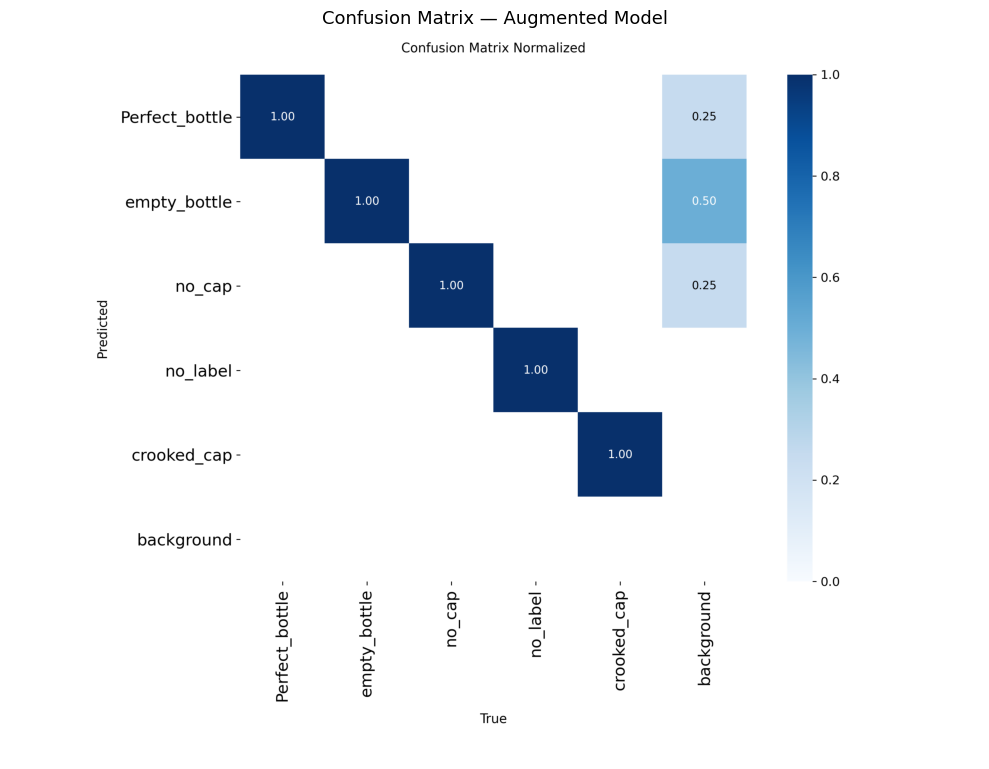

In [ ]:
#  CONFUSION MATRIX ANALYSIS
#  --- Which classes are being confused with each other? ---

# Confusion matrix is saved in the val run folder by YOLO (plots=True)
# Find and display it
aug_run_dir = WEIGHTS_DIR / 'experiment_augmented'
conf_matrix_path = aug_run_dir / 'confusion_matrix_normalized.png'

if conf_matrix_path.exists():
    img = cv2.imread(str(conf_matrix_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix — Augmented Model', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  Confusion matrix not found. Run training with plots=True to generate it.')

# How to read a YOLO confusion matrix:
#    Rows = predicted class, Columns = actual class.
#    Diagonal = correct predictions.
#    Off-diagonal = confusions. E.g., class 2 predicted as class 4 = similar appearance.
#    'Background FP' column = model hallucinating bottles where none exist.
#    'Background FN' row   = real bottles it missed entirely.

In [ ]:
#  VIDEO INFERENCE -- test on the video

TEST_VIDEO = Path('/content/drive/MyDrive/unzipped_Big_Cola/Video Projectbiggg.mp4')
OUTPUT_VIDEO = Path('/content/inference_output.mp4')

if TEST_VIDEO.exists():
    model_inference = YOLO(str(BEST_AUG))
    results = model_inference.predict(
        source     = str(TEST_VIDEO),
        conf       = 0.4,     # confidence threshold
        iou        = 0.45,    # NMS IoU threshold
        save       = True,
        project    = '/content',
        name       = 'inference_output',
        stream     = True,    # memory efficient for long videos
        verbose    = False
    )
    # Consume generator
    frame_count = sum(1 for _ in results)
    print(f'✅ Inference complete: {frame_count} frames processed')
    print(f'   Output saved to /content/inference_output/')
else:
    print(f'⚠️  Test video not found at: {TEST_VIDEO}')
    print('   Update TEST_VIDEO path and re-run.')



# NOTE: here for the conf=0.4 and iou=0.45 are standard starting points.
# conf threshold: lower -> more detections, more false positives
# iou threshold : lower -> more aggressive NMS (suppresses nearby boxes more)
# For a conveyor belt, we generally want conf >= 0.4 to reduce noise.

Results saved to /content/inference_output-2
✅ Inference complete: 560 frames processed
   Output saved to /content/inference_output/
